### 오늘의 목표
- 순환신경망을 이용하여 로이터 뉴스를 카테고리별로 분류해보자.
- 다양한 순환신경망에 대해 알아보자.

In [ ]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# 데이터 가져오기
from tensorflow.keras.datasets import reuters

In [ ]:
# 데이터 가져오기 (분할된 데이터 가져오기)
(X_train, y_train), (X_test, y_test) = reuters.load_data()

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(8982,)
(8982,)
(2246,)
(2246,)


In [ ]:
X_train
# 벡터화 된 상태 -> 이 데이터 활용만 하면된다.
# 문자열 -> 숫자변환 (정수 인코딩) 완료, 직접 전처리 하지 않아도 된다.
# 번호에 대해 글자를 알고 싶다면 단어사전 확인하기

array([list([1, 27595, 28842, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 4579, 1005, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 1245, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]),
       list([1, 3267, 699, 3434, 2295, 56, 16784, 7511, 9, 56, 3906, 1073, 81, 5, 1198, 57, 366, 737, 132, 20, 4093, 7, 19261, 49, 2295, 13415, 1037, 3267, 699, 3434, 8, 7, 10, 241, 16, 855, 129, 231, 783, 5, 4, 587, 2295, 13415, 30625, 775, 7, 48, 34, 191, 44, 35, 1795, 505, 17, 12]),
       list([1, 53, 12, 284, 15, 14, 272, 26, 53, 959, 32, 818, 15, 14, 272, 26, 39, 684, 70, 11, 14, 12, 3886, 18, 180, 183, 187, 70, 11, 14, 102, 32, 11, 29, 53, 44, 704, 15, 14, 19, 758, 15, 53, 959, 47, 1013, 15, 14, 19, 132, 15, 39, 965, 32, 11, 14, 147, 72, 11, 180, 183, 187, 44, 11, 14, 102, 19, 11, 123, 186, 90, 67, 960, 4

### 데이터확인
- 기존의 뉴스기사 데이터와 다른 형태의 데이터
- 이 데이터는 수치 변환 및 토큰화가 이미 진행되어 있는 데이터셋
- 사전에 전처리 이미 완료된 데이터이다.
- 우리가 전처리를 처음부터 하는것이 아닌 우리가 사용 할 형태에 맞춰서 진행만 해주면 된다.
- 빈도수를 기반으로 수치화를 진행한 데이터 -> 숫자가 작을 수록 많이 등장한 데이터이다.

In [ ]:
# 단어사전 확인
# 모델 입력을 위해 미리 만들어진 인덱스 사전
# 모든 문장은 이 사전을 기준으로 숫자로 변환됨
pd.Series(reuters.get_word_index()).sort_values()

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


,0
the,1
of,2
to,3
in,4
said,5
...,...
recirculation,30975
capco,30976
figueras,30977
jung,30978


In [ ]:
# 정답 종류 확인해보기
np.unique(y_train)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45])

### 정답 데이터 확인 결과
- 정답의 종류는 46종류 -> 다중분류
- 정답을 위한 원핫 인코딩 진행을 해야한다.
- 출력층 units :46 / acti : softmax
- loss 함수 : categorical_crossentropy

In [ ]:
# 정답데이터 원핫인코딩 진행
# 원핫인코딩 -> 분류(정해진것내에서 선택을 하게끔,제약을건다), 확률기반으로 동작
y_train_oh = pd.get_dummies(y_train)
y_test_oh = pd.get_dummies(y_test)

In [ ]:
# 문제 데이터 전처리 작업 진행
# 학습 데이터를 확인하여 길이를 맞춰주기 -> timesteps를 맞춰야 하기 때문 (데이터의 길이가 동일하다.)
# 순환횟수가 길어질 수록 깊이가 깊어질 수록 기억 손실이 발생 할 수 있다. -> 제대로된 분석이 되지않음.
# 길이가 짧을경우 0으로 채워서 확장하는 Padding기법을 사용 (문장의 의미를 해치지 않는선에서)
# 길이가 너무 길 경우에는 단어를 잘라서 축소 시키기 (데이터 손실 발생)

In [ ]:
# 데이터 확인
# 뉴스 문장에 적절한 길이를 찾기 위해 train 전체의 문장의 길이를 확인해보기
train_len = [] # 각 길이를 담을 리스트
for doc in X_train :
  train_len.append(len(doc))

In [ ]:
# 기술 통계량 확인
# 각 문장의 단어의 갯수
pd.Series(train_len).describe()
# 가장 많은 단어로 이루어진 문장 -> 2376개 단어 (기억 손실, 시간이 느림)
# 대부분 200개 내의 단어로 해결이 가능하다.

,0
count,8982.000000
mean,145.539857
std,145.822248
min,13.000000
25%,60.000000
50%,95.000000
75%,179.000000
max,2376.000000


### 데이터의 길이 확인 결과
- 최솟값 : 13
- 최댓값 : 2376
- 평균값 : 145
- 중앙값 : 95
- 75% : 179
- 무조건 최댓값에 맞춰서 데이터를 변형시킬 경우에는
순환횟수가 너무 많아져서 학습속도가 느려지고 기억 손실이 일어나 제대로 된 학습이 불가능
- 따라서 데이터 별로 길이를 확인하여 적절한 값으로 맞춰서 데이터를 사용해야 한다.
- 적절한 데이터의 길이는 150~200으로 추정
- 우리는 학습을 하는데 의의를 두기 위해 120정도로 설정

In [ ]:
# timestep을 120으로 설정하기
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
# 문장의 최대길이를 120으로 설정하여 짧은 문장의 경우에는 padding을 사용하여 0으로 채우고
# 긴 문장에 대해서는 120에 맞춰서 자르기
X_train_seq = pad_sequences(X_train, maxlen = 120)
X_test_seq = pad_sequences(X_test, maxlen = 120)

In [ ]:
print(X_train_seq[0])

[    0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     1 27595 28842
     8    43    10   447     5    25   207   270     5  3095   111    16
   369   186    90    67     7    89     5    19   102     6    19   124
    15    90    67    84    22   482    26     7    48     4    49     8
   864    39   209   154     6   151     6    83    11    15    22   155
    11    15     7    48     9  4579  1005   504     6   258     6   272
    11    15    22   134    44    11    15    16     8   197  1245    90
    67    52    29   209    30    32   132     6   109    15    17    12]


In [ ]:
print(X_train_seq[100])

[  936  1243     5   358   367   398    57    45  3680  7367     6  2394
  1343    13   373  4504    36     8  1440  5825     8    42   196   150
    10   523    96    34  9725    43    16  1261   205     7     4    65
   182  1351   367     6   351   184    45  6081  2286   197  1245    13
  3187 18631   274   419   714  1351   367   269    10    96    41   129
  1104  1673  1419   578    36   152 13394  1440  7615   367  1683   484
   293    75  6557     4  8042   152    24  5222    34   325   834     6
  1356 10043  2406     7     4    65    76  1082   164  1574   212     9
   861    34  8340    13   286  1930  1440  7615     8   787    36  1830
  1082    41  3751   616     6   382 13205 15185  1574  6928    17    12]


In [ ]:
X_train_seq.shape
# 벡터화된 상태, 그 데이터 자체를 feature로 가져가겠다? (차원만 늘려준다.)

(8982, 120)

In [ ]:
# 학습용문제데이터, 테스트용문제데이터 데이터 형태 확인
# (문장개수, 문장길이) 형태로 출력
print(X_train_seq.shape)
print(X_test_seq.shape)

(8982, 120)
(2246, 120)


In [ ]:
# 순환신경망을 사용하기 위해 특성 차원을 추가하기 (차원을 늘리기)
X_train_rs = X_train_seq.reshape(8982,120,1) # reshape.(X_train_seq.shape[0], X_train_seq.shape[1],1)
X_test_rs = X_test_seq.reshape(2246,120,1)

In [ ]:
# 순환신경망 사용하기 위한 데이터 전처리 완료
print(X_train_rs.shape)
print(X_test_rs.shape)
print(y_train_oh.shape)
print(y_test_oh.shape)

(8982, 120, 1)
(2246, 120, 1)
(8982, 46)
(2246, 46)


### 신경망 설계
- 순환신경망을 사용하기 위해 데이터셋 준비 완료
- 순환신경망을 사용해보기


In [ ]:
# 도구 불러오기
from tensorflow.keras import Sequential # 뼈대 도구
from tensorflow.keras.layers import Dense, SimpleRNN, InputLayer # 신경망 층 도구

In [ ]:
# SimpleRNN : 다층입력, 단층출력
# 일반적으로 RNN층은 여러 층 일수가 없다.
# 다층입력, 다층출력을 값을 바꿔주면 여러개의 순환신경망 층으로 쌓을 수 있다.
# (return_sequences = True)로 변경

# RNN RNN RNN MLP
#  T   T   F

### 순환신경망
- 일반적으로 순환신경망은 다층입력, 단층출력의 구조를 가지고 있다.
- 여러개의 순환신경망을 쌓을때는 다층입력, 다층출력 구조로 변경 해줘야 한다.
- return_sequences = True 를 해줘야만 다층출력 구조를 변경 할 수 있다.

In [ ]:
from numpy._core.fromnumeric import shape

In [ ]:

# 신경망 구축
# 뼈대 생성
model1 = Sequential()

# 입력층 쌓기
model1.add(InputLayer(shape=(120,1))) # 입력 데이터 특성에 맞춰서 설정

# RNN층
model1.add(SimpleRNN(units = 128, activation='tanh', return_sequences=True))
model1.add(SimpleRNN(units = 64, activation='tanh', return_sequences=True))
model1.add(SimpleRNN(units = 32, activation='tanh'))
# ================================= RNN층 =====================================
# MLP층
model1.add(Dense(units=64, activation='relu'))

# 출력층
model1.add(Dense(units=46, activation='softmax'))

In [ ]:
# 모델 학습방법 및 평가방법 설정
model1.compile(
    loss='categorical_crossentropy',
    optimizer = 'adam',
    metrics=['accuracy']
)

In [ ]:
# 모델 학습 진행
model1.fit(X_train_rs, y_train_oh,
           epochs = 50,
           validation_split = 0.2
           )

Epoch 1/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.3452 - loss: 2.4928 - val_accuracy: 0.3561 - val_loss: 2.3738
Epoch 2/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.3900 - loss: 2.3352 - val_accuracy: 0.3728 - val_loss: 2.2796
Epoch 3/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.3839 - loss: 2.3201 - val_accuracy: 0.4196 - val_loss: 2.2702
Epoch 4/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.3569 - loss: 2.3605 - val_accuracy: 0.3450 - val_loss: 2.3587
Epoch 5/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.3640 - loss: 2.3376 - val_accuracy: 0.3589 - val_loss: 2.3359
Epoch 6/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.3762 - loss: 2.3162 - val_accuracy: 0.3723 - val_loss: 2.3114
Epoch 7/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.3873 - loss: 2.2922 - val_accuracy: 0.3662 - val_loss: 2.3211
Epoch 8/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.3876 - loss: 2.2777 - val_ac

In [ ]:
# SimpleRNN은 기억손실이 잘 일어난다. -> 다른 RNN 있음
# 데이터의 길이가 길때는 좋은방법이 아니다.

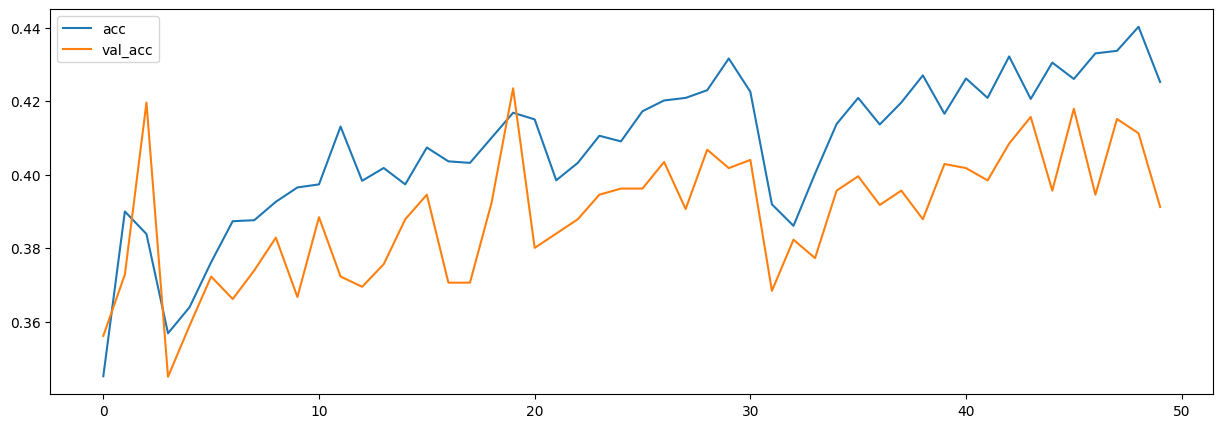

In [ ]:
# 시각화 진행
plt.figure(figsize=(15,5))
plt.plot(model1.history.history['accuracy'], label='acc')
plt.plot(model1.history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

In [ ]:
# epoch를 많이 돌린다고 해서 성능이 좋아지는것 아님 -> 과적합 발생
# 굳이 epoch를 더 돌릴 필요 없다. early-stop

### 결과 확인
- 정확도가 향상이 되면서 학습이 진행되고 있지만 높은편은 아니다.

### 성능을 높이는 방법
- 더 좋은 성능의 모델사용
- 데이터 전처리 진행 (빈도기반이 아닌 의미 분석을 위한 고차원의 벡터화 방법을 사용(임베딩))
- 많은 데이터 확보
- 파라미터 값 조정 등

### RNN 모델 특징
 - 기본적인 RNN 구조는 긴 시퀀스를 가지는 데이터를 효과적으로 학습하기는 어렵다.
 - 문장의 길이가 엄청 길지는 않더라도, RNN성능은 조금만 길이가 길어지면 기억손실이 일어나 성능이 떨어질 가능성이 매우 높다.
 - 순환횟수가 길어질 수록 초반 입력된 단어의 기억 데이터가 손실되는 현상이 발생
 - 문장 구성시 초반 단어가 후반단어에 영향을 많이 끼치는 데이터일수록 SimpleRNN의 성능은 좋지 않을 가능성이 높다.

### 단점을 보완한 모델
####  LSTM(Long Short Term Memory)
- 장기기억, 단기기억에 대해 관리계산이 추가된 모델
- 연산이 복잡해져 학습이 오래 걸리고 모델이 무겁지만 기억 손실이 줄어들어 성능 면에서는 좋을 가능성이 높다.

In [ ]:
# LSTM 불러오기
from tensorflow.keras.layers import LSTM

In [ ]:
# 신경망 구현
model2 = Sequential()

# 입력층
model2.add(InputLayer(shape=(120,1)))

# LSTM층 쌓기
model2.add(LSTM(units = 128, activation = 'tanh', return_sequences=True))
model2.add(LSTM(units = 64, activation = 'tanh', return_sequences=True))
model2.add(LSTM(units = 32, activation = 'tanh'))
#------------------------------ LSTM 층 -------------------------------------
# MLP층 쌓기
model2.add(Dense(units=64, activation='relu'))
# 출력층 쌓기
model2.add(Dense(units=46, activation='softmax'))

In [ ]:
# 학습방법 및 평가방법 설정
model2.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
# 모델 학습
model2.fit(
    X_train_rs, y_train_oh,
    epochs=20,
    validation_split=0.2
)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.4015 - loss: 2.3493 - val_accuracy: 0.4552 - val_loss: 2.1488
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.4527 - loss: 2.1459 - val_accuracy: 0.4619 - val_loss: 2.1149
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.4619 - loss: 2.1029 - val_accuracy: 0.4630 - val_loss: 2.0719
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.4675 - loss: 2.0730 - val_accuracy: 0.4758 - val_loss: 2.0482
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.4721 - loss: 2.0447 - val_accuracy: 0.4663 - val_loss: 2.0384
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.4717 - loss: 2.0254 - val_accuracy: 0.4624 - val_loss: 2.0334
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.4681 - loss: 2.0135 - val_accuracy: 0.4797 - val_loss: 1.9982
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.4778 - loss: 1.9871 - val_acc

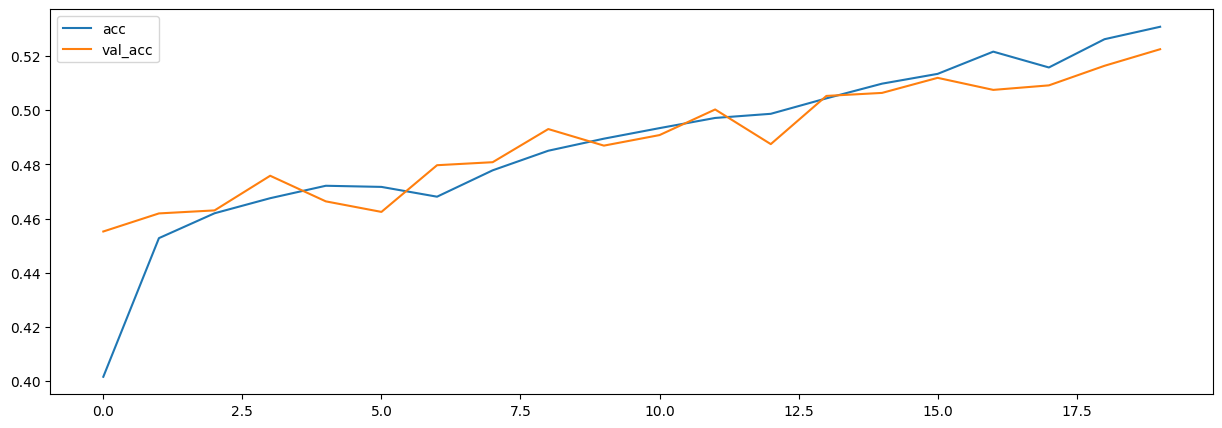

In [ ]:
# 시각화 진행
plt.figure(figsize=(15,5))
plt.plot(model2.history.history['accuracy'], label='acc')
plt.plot(model2.history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

# 20260421

### 임베딩 레이어 추가하기
- 현재 로이터 뉴스는 단어사전에 부여된 번호 패턴을 보고 학습하는 구조
- 각 단어의 의미를 학습시키려면 임베딩 레이어를 추가
- 각단어의 관계성을 보기 위해 임베딩 레이어 추가

In [ ]:
from tensorflow.keras.layers import Embedding # 임베딩레이어

In [ ]:
# 뼈대 구성
model = Sequential()

# 입력층
model.add(InputLayer(shape=(120,)))
# 임베딩레이어 : 학습을 통해서 입력된 데이터(단어)의 정보를 정교한 실수형태로 학습하거나 변환하는 레이어
# input_dim = 단어사전에 등록된 단어 수 -> 임베딩 벡터의 갯수를 의미
# oov -> 없는단어가 들어올 경우, 무시하고 추론 하거나 다시 학습시켜서
# output_dim = 한 단어를 표현하는 숫자의 갯수, 데이터양과 모델 사이즈를 고려해 숫자 잡기
model.add(Embedding(input_dim=30979, output_dim=120))
# 중간층
model.add(LSTM(units = 128, activation = 'tanh', return_sequences=True))
model.add(LSTM(units = 64, activation = 'tanh', return_sequences=True))
model.add(LSTM(units = 32, activation = 'tanh'))
model.add(Dense(units=64, activation='relu'))
# 출력층
model.add(Dense(units=46, activation='softmax'))

In [ ]:
model.compile(loss="categorical_crossentropy",
              optimizer="adam",
              metrics=['accuracy'])

In [ ]:
# optimizer="adam"
# 경사하강법 종류
# 오차에 대한 방향성을 어떻게 할것인가?
# 기울기 = y의 변화량/x의 변화량
# 기울기 -> x가 변할 때 y가 어떻게 변하는가? -> 증가인지 감소인지
# 딥러닝에서 기울기 = loss / w의 변화량
# -> w나 b가 변화 했을때 loss가 증가 (+), loss가 감소 (-) -> w를 내릴지 올릴지를 판단 할 수 있다.

In [ ]:
model.fit(X_train_rs, y_train_oh, epochs=40, validation_split=0.2)
# model.fit(X_train_rs, y_train_oh, epochs=20)
# keras는 연속학습이 된다. 지금 코드를 한번 더 실행시키면 40번 학습이 되는것
# validation_split=0.2 넣어줘야 검증데이터에 대한 결과도 볼 수 있다.

Epoch 1/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.3367 - loss: 2.5159 - val_accuracy: 0.3450 - val_loss: 2.4119
Epoch 2/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.3534 - loss: 2.4117 - val_accuracy: 0.3450 - val_loss: 2.4186
Epoch 3/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.3534 - loss: 2.4114 - val_accuracy: 0.3450 - val_loss: 2.4137
Epoch 4/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.3534 - loss: 2.4102 - val_accuracy: 0.3450 - val_loss: 2.3649
Epoch 5/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.4186 - loss: 2.1263 - val_accuracy: 0.5003 - val_loss: 1.8680
Epoch 6/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.5104 - loss: 1.8310 - val_accuracy: 0.5342 - val_loss: 1.7660
Epoch 7/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5532 - loss: 1.6832 - val_accuracy: 0.5314 - val_loss: 1.7676
Epoch 8/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.5765 - loss: 1.6156 - val_acc

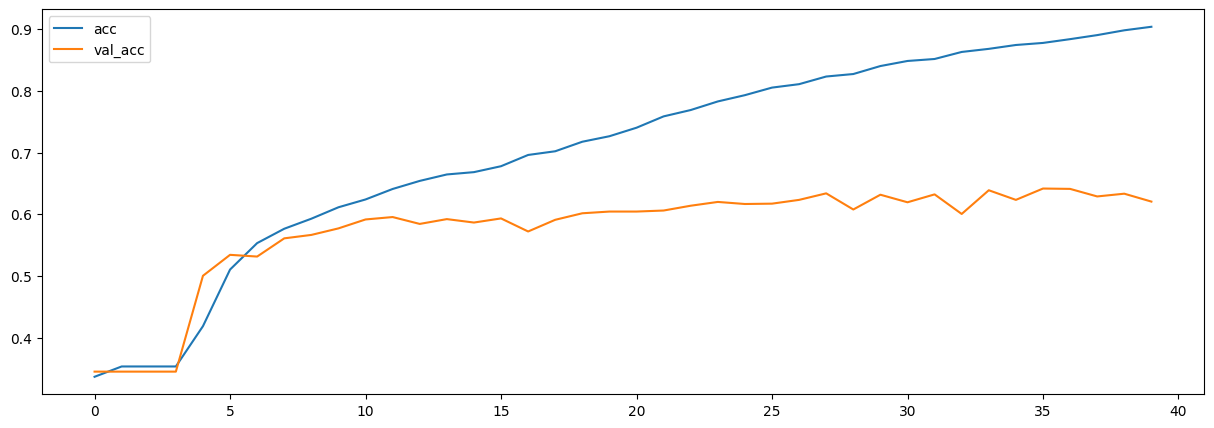

In [ ]:
# 시각화 진행
plt.figure(figsize=(15,5))
plt.plot(model.history.history['accuracy'], label='acc')
plt.plot(model.history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

In [ ]:
# 훈련데이터에 대한 이해도는 올라가고 있지만 새로운 데이터에 대해서는 성능이 좋지 못한 상황이다.

### 모델 수정해보기
- 현재 모델은 훈련데이터에 대한 이해도가 빠르게 올라갔지만 검증데이터에 대한 이해도는 일정수준에 그친다.
- 모델 구조, 단어사전의 수 등을 변경해서 개선이 가능한지 실습해보자

In [ ]:
# 모델구조 변경
# 뼈대 구성
model = Sequential()

# 입력층
model.add(InputLayer(shape=(120,)))
model.add(Embedding(input_dim=30979, output_dim=128))
# 중간층
model.add(LSTM(units = 128, activation = 'tanh'))
# 출력층
model.add(Dense(units=46, activation='softmax'))

In [ ]:
model.compile(loss="categorical_crossentropy",
              optimizer="adam",
              metrics=['accuracy'])

In [ ]:
model.fit(X_train_rs, y_train_oh, epochs=40, validation_split=0.2)

Epoch 1/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4541 - loss: 2.1825 - val_accuracy: 0.4597 - val_loss: 2.0131
Epoch 2/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5294 - loss: 1.8484 - val_accuracy: 0.5498 - val_loss: 1.7249
Epoch 3/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5768 - loss: 1.6282 - val_accuracy: 0.5665 - val_loss: 1.7207
Epoch 4/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6388 - loss: 1.3727 - val_accuracy: 0.6227 - val_loss: 1.4922
Epoch 5/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6938 - loss: 1.1651 - val_accuracy: 0.6183 - val_loss: 1.5388
Epoch 6/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7588 - loss: 0.9204 - val_accuracy: 0.6594 - val_loss: 1.4695
Epoch 7/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8035 - loss: 0.7438 - val_accuracy: 0.6522 - val_loss: 1.5139
Epoch 8/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8447 - loss: 0.5995 - val_accu

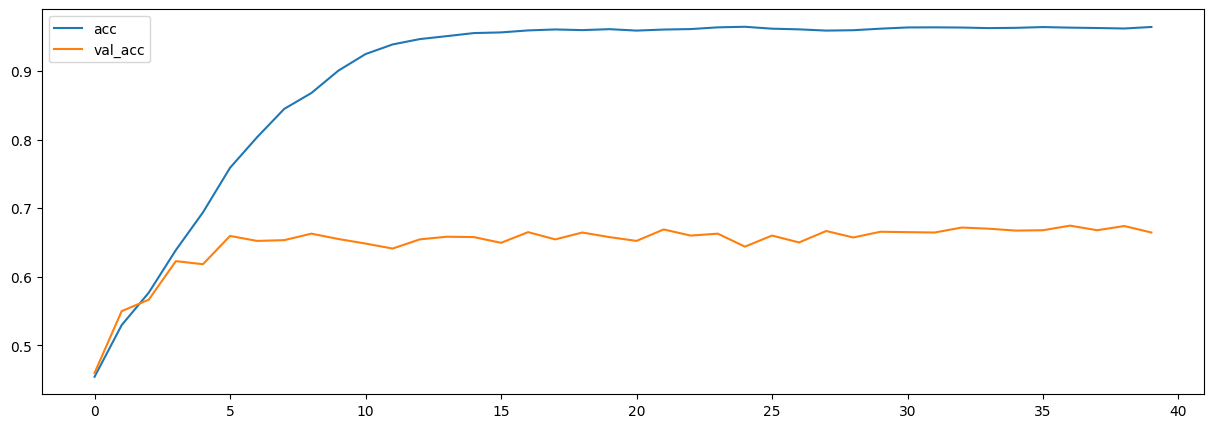

In [ ]:
# 시각화 진행
plt.figure(figsize=(15,5))
plt.plot(model.history.history['accuracy'], label='acc')
plt.plot(model.history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

In [ ]:
# 훈련데이터에대해 정확도가 조금 더 빠르게 올라감을 알 수 있었다.
# 검증데이터에대한 점수도 조금 더 개선된것을 볼 수 있었다.

In [ ]:
# 단어사전 수, 임베딩벡터 길이 조절해보기
# 데이터 가져오기 (분할된 데이터 가져오기)
# 단어 빈도 파악해 -> 최소빈도를 책정해 기준을 정해서 그 이상만 보게
# num_words -> 빈도가 높은 상위 8000개 단어만 단어사전에 등록해서 활용하기
(X_train, y_train), (X_test, y_test) = reuters.load_data(num_words=8000)

In [ ]:
X_train_seq = pad_sequences(X_train, maxlen = 120)
X_test_seq = pad_sequences(X_test, maxlen = 120)
X_train_rs = X_train_seq.reshape(8982,120,1)
X_test_rs = X_test_seq.reshape(2246,120,1)

In [ ]:
# 뼈대 구성
model = Sequential()

# 입력층
model.add(InputLayer(shape=(120,)))
model.add(Embedding(input_dim=8000, output_dim=128))
# 중간층
model.add(LSTM(units = 128, activation = 'tanh'))
# 출력층
model.add(Dense(units=46, activation='softmax'))

In [ ]:
model.compile(loss="categorical_crossentropy",
              optimizer="adam",
              metrics=['accuracy'])

In [ ]:
model.fit(X_train_rs, y_train_oh, epochs=40, validation_split=0.2)

Epoch 1/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4191 - loss: 2.2289 - val_accuracy: 0.4413 - val_loss: 1.9994
Epoch 2/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5166 - loss: 1.8172 - val_accuracy: 0.5348 - val_loss: 1.7735
Epoch 3/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5596 - loss: 1.7155 - val_accuracy: 0.5704 - val_loss: 1.7158
Epoch 4/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5983 - loss: 1.5768 - val_accuracy: 0.5993 - val_loss: 1.5744
Epoch 5/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6640 - loss: 1.3359 - val_accuracy: 0.6316 - val_loss: 1.4544
Epoch 6/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7122 - loss: 1.1378 - val_accuracy: 0.6550 - val_loss: 1.4067
Epoch 7/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7628 - loss: 0.9494 - val_accuracy: 0.6633 - val_loss: 1.4016
Epoch 8/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8007 - loss: 0.7916 - val_accu

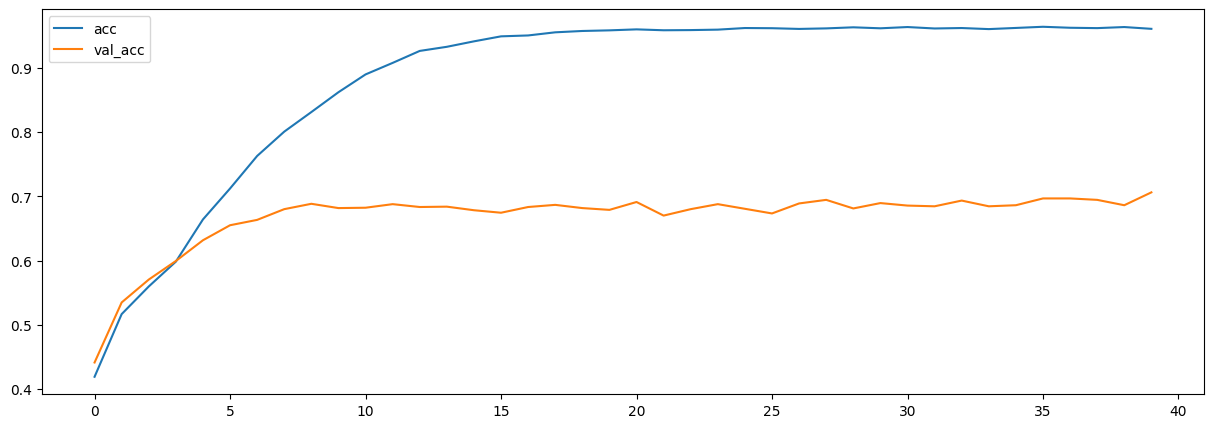

In [ ]:
# 시각화 진행
plt.figure(figsize=(15,5))
plt.plot(model.history.history['accuracy'], label='acc')
plt.plot(model.history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

In [ ]:
# 단어수는 크게 영향이 없다. 성능이 비슷하기 때문에 모델의 경량화 진행

### 임베딩 벡터 만들기 실습
- 임베딩 벡터를 만드는것이 목적인 모델사용<hr>
- 구글에서 발표한 Word2Vec 모델을 사용
- Word2Vec 단어끼리의 관계성을 통해 단어의 의미를 정교한 실수로 만들어내는 것을 최종 목적으로 둔 모델
- 이후에 Glove, FastText 등이 등장 했고, 현대 LLM은 임베딩을 기본적으로 탑재해서 활용하고 있다.

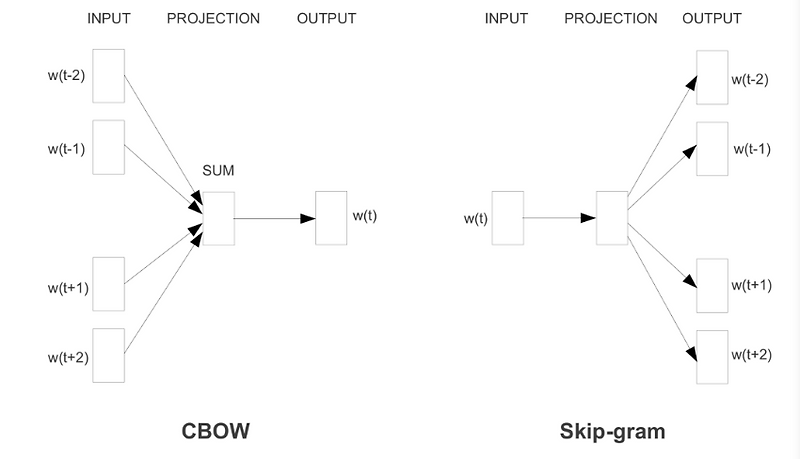

In [1]:
# 필요 패키지 설치
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.6 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

In [ ]:
naver_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/딥러닝/data/naver_shopping (1).txt",
                       delimiter="\t", header=None
                       )

In [ ]:
naver_df.columns = ['평점', '리뷰']
naver_df.head()

,평점,리뷰
0,5,배공빠르고 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ


In [ ]:
!pip install kiwipiepy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 10.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 12.3 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.23.0-py3-none-any.whl size=88067826 sha256=67ebebec63dc421703aca7b5ab90a7237d88583ce4d64f29035d45c1e15b6fbb
  Stored in directory: /root/.cache/pip/wheels/f2/94/da/ff88b4c2305cd1f3effc8001b5f42f16dc9931bcd84d1e77c3
Successfully built kiwipiepy_model


In [ ]:
from kiwipiepy import Kiwi
kiwi = Kiwi()

In [ ]:
naver_df['형태소'] = naver_df['리뷰'].apply(lambda x : kiwi.tokenize(x))

In [ ]:
naver_df.head()

,평점,리뷰,형태소
0,5,배공빠르고 굿,"[(배, NNG, 0, 1), (공, NNG, 1, 1), (빠르, VA, 2, 2..."
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,"[(택배, NNG, 0, 2), (가, JKS, 2, 1), (엉망, NNG, 4,..."
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,"[(아주, MAG, 0, 2), (좋, VA, 2, 1), (어요, EF, 3, 2..."
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,"[(선물, NNG, 0, 2), (용, XSN, 2, 1), (으로, JKB, 3,..."
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,"[(민트, NNG, 0, 2), (색상, NNG, 2, 2), (예쁘, VA, 5,..."


In [ ]:
naver_df['형태소'].iloc[0]

[Token(form='배', tag='NNG', start=0, len=1),
 Token(form='공', tag='NNG', start=1, len=1),
 Token(form='빠르', tag='VA', start=2, len=2),
 Token(form='고', tag='EC', start=4, len=1),
 Token(form='굿', tag='NNG', start=6, len=1)]

In [ ]:
# 품사가 명사, 형용사, 동사인 단어 필터링
# 리스트컴프리핸션 사용해 반복문 사용
naver_df['형태소_필터링'] = naver_df['형태소'].apply(lambda x : [token.form for token in x if token.tag in ["VV","VA","NNG"]])

In [ ]:
naver_df.head()

,평점,리뷰,형태소,형태소_필터링
0,5,배공빠르고 굿,"[(배, NNG, 0, 1), (공, NNG, 1, 1), (빠르, VA, 2, 2...","[배, 공, 빠르, 굿]"
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,"[(택배, NNG, 0, 2), (가, JKS, 2, 1), (엉망, NNG, 4,...","[택배, 엉망, 집, 밑, 층, 말, 놔두, 가]"
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,"[(아주, MAG, 0, 2), (좋, VA, 2, 1), (어요, EF, 3, 2...","[좋, 바지, 좋, 구매, 가격, 대박, 바느질, 편하, 가성비, 최고]"
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,"[(선물, NNG, 0, 2), (용, XSN, 2, 1), (으로, JKB, 3,...","[선물, 전달, 상품, 머그, 컵, 오, 당황, 전화, 주, 하, 배송, 누락, 확..."
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,"[(민트, NNG, 0, 2), (색상, NNG, 2, 2), (예쁘, VA, 5,...","[민트, 색상, 예쁘, 옆, 손잡이, 용도, 사용]"


In [ ]:
# 학습
import gensim.models

model = gensim.models.Word2Vec(
    sentences = naver_df['형태소_필터링'], # 학습시킬 데이터셋
    sg = 1, # 1은 skip-gram방식 / 0은 CBOW방식
    window = 3, # 중심단어와 주변단어(양쪽으로)의 관계를 어느 거리까지 볼껀지 설정
    min_count = 5, # 단어의 최소 등장하는 횟수
    vector_size = 50 # 단어를 임베딩 할 벡터 크기
)

In [ ]:
# 임베딩 벡터 확인
keyword = '민트'
keyword_vector = model.wv[keyword]

In [ ]:
keyword_vector

array([ 0.07798149, -0.61794955,  0.03081303, -0.0591892 , -0.21177101,
        0.35532925,  0.08010247,  0.45970514, -0.20262574, -0.05253665,
       -0.04861845, -0.47573677,  0.4405958 ,  0.23687732, -0.55296683,
        0.52501833,  0.23514993,  0.32286137,  0.37801006, -0.69767463,
        0.5825388 ,  0.15775914,  0.9801137 , -0.16596143,  0.17526129,
        0.15721342, -0.8041982 ,  0.37339744, -0.61700284,  0.95021915,
       -0.39878502,  0.20866978,  0.05551976, -0.6427552 , -0.3211389 ,
        0.27039337, -0.03142499, -0.55684847, -0.1569526 ,  0.13441545,
        0.6346536 ,  0.03055219, -0.49097067, -0.01414665,  0.19937018,
       -0.31858346, -0.35674512, -0.50237525,  0.49882564,  0.14720054],
      dtype=float32)

In [ ]:
# 연관단어 확인하기
keyword = '민트'
rs = model.wv.most_similar(keyword, topn=20)

In [ ]:
rs

[('카키', 0.9170218110084534),
 ('오렌지', 0.9118677973747253),
 ('레드', 0.905279278755188),
 ('계열', 0.9015922546386719),
 ('빨강', 0.9003015756607056),
 ('그린', 0.8959783315658569),
 ('노랑', 0.8944131731987),
 ('하늘색', 0.8912338018417358),
 ('파스텔', 0.890152096748352),
 ('짙', 0.8849723935127258),
 ('찐하', 0.8758903741836548),
 ('카키색', 0.8732895851135254),
 ('실버', 0.8720675110816956),
 ('고동색', 0.8714878559112549),
 ('연보라', 0.8690088391304016),
 ('옐로우', 0.864913284778595),
 ('브라운', 0.8647906184196472),
 ('딥', 0.8643546104431152),
 ('은은하', 0.8638688325881958),
 ('블루', 0.8632349371910095)]

In [ ]:
# 임베딩 벡터 확인
keyword = '택배'
keyword_vector = model.wv[keyword]
keyword_vector

# 연관단어 확인하기
keyword = '택배'
rs = model.wv.most_similar(keyword, topn=20)
rs

[('화물', 0.7977681159973145),
 ('우체국', 0.7883020639419556),
 ('업체', 0.7844327092170715),
 ('배달', 0.7770397663116455),
 ('무인', 0.7746832966804504),
 ('물류', 0.7745092511177063),
 ('분실', 0.7696690559387207),
 ('파업', 0.7684641480445862),
 ('운송', 0.7609013915061951),
 ('찾아가', 0.7561967968940735),
 ('경비실', 0.7510141134262085),
 ('거래', 0.7499322891235352),
 ('죄송하', 0.7498522400856018),
 ('조회', 0.7476325035095215),
 ('항의', 0.7475365400314331),
 ('회사', 0.7471755743026733),
 ('신선식품', 0.7458096742630005),
 ('주소지', 0.7401072978973389),
 ('물건', 0.7363243699073792),
 ('사정', 0.7355663180351257)]